In [1]:
!pip install torchio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.6/203.6 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 4.3 MB/s eta 0:00:00


In [2]:
import numpy as np
from PIL import Image
import pandas as pd
from typing import Union
import torch
import warnings
import os

import cv2
import matplotlib.pyplot as plt

import seaborn as sns
import tqdm
import io 
import nibabel as nib
import torch 
from torchvision.transforms import v2
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchio

warnings.filterwarnings("ignore")

In [4]:
train = pd.read_csv('/kaggle/input/uw-madison-gi-tract-image-segmentation/train.csv')
train

,id,class,segmentation
0,case123_day20_slice_0001,large_bowel,NaN
1,case123_day20_slice_0001,small_bowel,NaN
2,case123_day20_slice_0001,stomach,NaN
3,case123_day20_slice_0002,large_bowel,NaN
4,case123_day20_slice_0002,small_bowel,NaN
...,...,...,...
115483,case30_day0_slice_0143,small_bowel,NaN
115484,case30_day0_slice_0143,stomach,NaN
115485,case30_day0_slice_0144,large_bowel,NaN
115486,case30_day0_slice_0144,small_bowel,NaN


In [5]:
import gc
def empty_cached():
  gc.collect()
  torch.cuda.empty_cache()

In [ ]:
train = old_train.copy()

In [6]:

for i in range(0, train.shape[0], 3):
    train['segmentation'].iloc[i] = train['segmentation'].iloc[i:i+3].tolist()

train = train[::3]
train.reset_index(drop = True, inplace = True)

In [ ]:
old_train = train.copy()

In [11]:
train['path']     = '/kaggle/input/uw-madison-gi-tract-image-segmentation/train/'
train['splitted'] = train.id.agg(lambda x: x.split('_'))
train['case']     = train.splitted.agg(lambda x: str(x[0]))
train['day']      = train.splitted.agg(lambda x: str(x[1]))
train['slice']    = train.splitted.agg(lambda x: int(x[3].lstrip('0')))


cases = train.case.value_counts(sort = False)
cases_val, case_iter = cases.index, cases.values
case_iter = np.insert(case_iter, 0, 0)
case_iter = np.cumsum(case_iter)

for i in range(1, case_iter.shape[0]):
    
    temp_data = train.loc[case_iter[i-1]:case_iter[i]-1]

    days = temp_data.day.value_counts(sort = False)
    day_val, day_iter = days.index, days.values

    day_iter = np.insert(day_iter, 0, 0)
    day_iter = np.cumsum(day_iter)

    for j in range(1, day_iter.shape[0]):
        
        first_idx = case_iter[i-1]+day_iter[j-1]
        second_idx = day_iter[j]+case_iter[i-1]-1

        val = cases_val[i-1]+'/'+cases_val[i-1]+'_'+day_val[j-1]+'/'+'scans/'
        
        train['path'].loc[first_idx] +=  val

        train['segmentation'].loc[first_idx] = train['segmentation'].loc[first_idx:second_idx].tolist()

        train.drop(train.loc[first_idx+1:second_idx].index, 
               inplace = True)

train.reset_index(inplace = True, drop = True)
train

,id,class,segmentation,path,splitted,case,day,slice
0,case123_day20_slice_0001,large_bowel,"[[nan, nan, nan], [nan, nan, nan], [nan, nan, ...",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case123, day20, slice, 0001]",case123,day20,1
1,case123_day22_slice_0001,large_bowel,"[[nan, nan, nan], [nan, nan, nan], [nan, nan, ...",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case123, day22, slice, 0001]",case123,day22,1
2,case123_day0_slice_0001,large_bowel,"[[nan, nan, nan], [nan, nan, nan], [nan, nan, ...",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case123, day0, slice, 0001]",case123,day0,1
3,case77_day20_slice_0001,large_bowel,"[[nan, nan, nan], [nan, nan, nan], [nan, nan, ...",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case77, day20, slice, 0001]",case77,day20,1
4,case77_day0_slice_0001,large_bowel,"[[nan, nan, nan], [nan, nan, nan], [nan, nan, ...",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case77, day0, slice, 0001]",case77,day0,1
...,...,...,...,...,...,...,...,...
269,case74_day0_slice_0001,large_bowel,"[[nan, nan, nan], [nan, nan, nan], [nan, nan, ...",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case74, day0, slice, 0001]",case74,day0,1
270,case74_day13_slice_0001,large_bowel,"[[nan, nan, nan], [nan, nan, nan], [nan, nan, ...",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case74, day13, slice, 0001]",case74,day13,1
271,case74_day18_slice_0001,large_bowel,"[[nan, nan, nan], [nan, nan, nan], [nan, nan, ...",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case74, day18, slice, 0001]",case74,day18,1
272,case30_day1_slice_0001,large_bowel,"[[nan, nan, nan], [nan, nan, nan], [nan, nan, ...",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case30, day1, slice, 0001]",case30,day1,1


In [12]:
from sklearn.model_selection import train_test_split
cases = train.case.unique()
cases_train, cases_valid = train_test_split(
   cases, test_size=0.1, random_state=42
)
cases_train
trainset, validset = train[train['case'].isin(cases_train)], \
                     train[train['case'].isin(cases_valid)]

In [13]:

def RLE_masking(rle_arr: np.array(str | None ), 
                shape: (3, int, int, int)) -> torch.Tensor:
    """
    Ouput: np.array[Depth, Channels(3), Height, Width] of RLE masks
    for original(not transformed) 3D Object"
    """
    
    RLE = torch.zeros((shape[1], shape[0], shape[2], shape[3]))
    for j in range(shape[1]):

        for i in range(shape[0]):
            if pd.isna(rle_arr[j][i]):
                continue
    
            rle = list(map(int, rle_arr[j][i].split()))
            start_pixel, len_of_masking = rle[::2], rle[1::2]
            temp = torch.zeros((shape[2]*shape[3]))
            
            masking = torch.hstack(
                [torch.arange(start_pixel[i], start_pixel[i]+len_of_masking[i])
                                for i in range(len(start_pixel))]) 
            
            temp[masking] = 1 
            RLE[j][i] = temp.reshape((shape[2], shape[3]))
    
    return RLE

def load_img(path: str) -> np.array:
    """
    Output min-max scaled np.array[C, H, W]
    """
    img = cv2.imread(path, cv2.IMREAD_ANYDEPTH)
    img = (img - img.min()) / (img.max() - img.min() + 1e-9)
    img = (img*255).astype(np.float32)    
    return img

def to_3d_object(path: str) -> torch.tensor:
    """
    Output torch.Tensor[D, C(1), H, W]
    """
    paths = [os.path.join(path, file) for file in sorted(os.listdir(path))]
    tensor_list = [v2.functional.to_tensor(load_img(path)) for path in paths]
    tensor_3d = torch.stack(tensor_list, dim=0)
    
    return tensor_3d

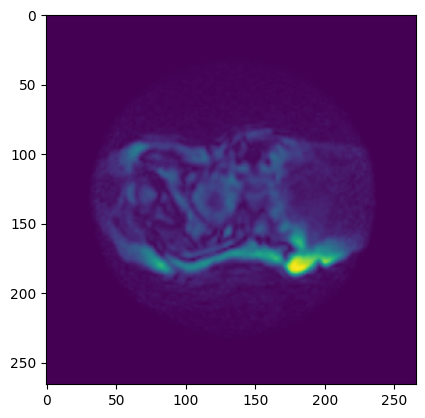

In [14]:
а = to_3d_object(trainset.loc[3].path)
b = а[0][0]
fig,ax = plt.subplots()
ax.imshow(b)
plt.show()

In [16]:
train_dir, valid_dir =  os.path.join('/kaggle/working/', 'train/'), \
                        os.path.join('/kaggle/working/', 'valid/')

train_obj_dir, train_mask_dir = os.path.join(train_dir, 'objects/'), \
                                os.path.join(train_dir, 'masks/')

valid_obj_dir, valid_mask_dir = os.path.join(valid_dir, 'objects/'), \
                                os.path.join(valid_dir, 'masks/')

to_check_existing_path = [train_obj_dir, train_mask_dir, 
                          valid_obj_dir, valid_mask_dir]

for path in to_check_existing_path:
    if not os.path.isdir(path):
        os.makedirs(path)


In [17]:
dtype, compress = np.float32, None
device = 'cuda'

def tensor_to_gz(data: pd.DataFrame, 
                 file_dir: (str, str),
                 dtype: torch.dtype,
                 compress: tuple | None = None,
                 transform: v2.Compose = None) -> None:
    
    obj_dir, masks_dir = file_dir[0], file_dir[1]
    n = data.shape[0]
    affine = np.eye(4)   
    
    for idx in tqdm.tqdm(range(n), desc ="Converting objects and labels into niftiImage"):
        
        item = data.iloc[idx]    
        to_save_path = item['case']+item['day']
        
        object_3d = to_3d_object(item['path'])

        depth, height, width = object_3d.shape[0], object_3d.shape[2], object_3d.shape[3]
        
        masks = RLE_masking(item['segmentation'], 
                                 (3, depth, height, width))
        
        if compress:
            object_3d = object_3d[:, :, ::compress[0], ::compress[1]]
            masks     = masks[:, :, ::compress[0], ::compress[1]]
            
        object_3d, masks = object_3d.permute(1, 3, 2, 0), masks.permute(1, 3, 2, 0)
        
        object_3d, masks = object_3d.detach().cpu().numpy().astype(dtype), \
                           masks.detach().cpu().numpy().astype(dtype)
 
        object_3d, masks = nib.Nifti1Image(object_3d, affine), \
                           nib.Nifti1Image(masks, affine)
        
        
        nib.save(object_3d, obj_dir+f"_image({idx}).nii.gz")
        nib.save(masks, masks_dir+f"_masks({idx}).nii.gz")
        

In [18]:

tensor_to_gz(data = trainset, file_dir = (train_obj_dir, train_mask_dir),
             dtype = dtype, compress = None)

tensor_to_gz(data = validset, file_dir = (valid_obj_dir, valid_mask_dir),
             dtype = dtype, compress = None)

Converting objects and labels into niftiImage: 100%|██████████| 29/29 [01:29<00:00,  3.10s/it]


In [19]:

objects_train, masks_train = sorted(os.path.join(train_obj_dir, path) for path in os.listdir(train_obj_dir)), \
                             sorted(os.path.join(train_mask_dir, path) for path in os.listdir(train_mask_dir))


objects_valid, masks_valid = sorted(os.path.join(valid_obj_dir, path) for path in os.listdir(valid_obj_dir)), \
                             sorted(os.path.join(valid_mask_dir, path) for path in os.listdir(valid_mask_dir))



In [20]:
import torchio as tio
#D, C, W, H
train_tio_subjects = [tio.Subject(one_image=tio.ScalarImage(object_path),
                            a_segmentation=tio.LabelMap(label_path)) 
                            for object_path, label_path in zip(objects_train, masks_train)]

valid_tio_subjects =  [tio.Subject(one_image=tio.ScalarImage(object_path),
                            a_segmentation=tio.LabelMap(label_path)) 
                            for object_path, label_path in zip(objects_valid, masks_valid)] 

Subject(Keys: ('one_image', 'a_segmentation'); images: 2)
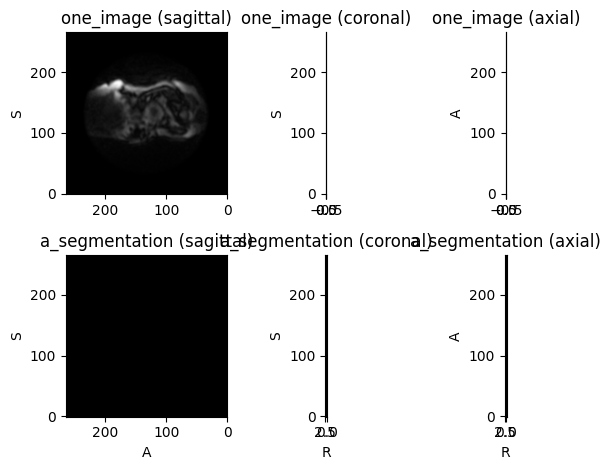

In [21]:
train_tio_subjects[0]

In [22]:
class FixingAxes(tio.IntensityTransform):
    def __init__(self):
        super().__init__()

    def apply_transform(self, subject: tio.Subject) -> tio.Subject:
        #D,C, H, W -> C, H, W, D
        for image in subject.get_images(intensity_only=False):
            image.data = image.data.permute(1,2,3,0)
        return subject

In [27]:
'''
transform = tio.Compose([FixingAxes(), tio.ToCanonical(),       
        tio.RandomFlip(axes=(0,1,2), p=0.5, include = ['one_image', 'a_segmentation']),
        tio.RandomAffine(p=0.5, include = ['one_image', 'a_segmentation']),
        tio.RandomElasticDeformation(p=0.5, include = ['one_image', 'a_segmentation']),
        tio.RandomNoise(include = ['one_image'])])
'''
transform = tio.Compose([FixingAxes()])

In [28]:

train_subjects_dataset = tio.SubjectsDataset(train_tio_subjects, 
                                             transform = transform)
valid_subjects_dataset = tio.SubjectsDataset(valid_tio_subjects, 
                                             transform = transform)

Subject(Keys: ('one_image', 'a_segmentation'); images: 2)
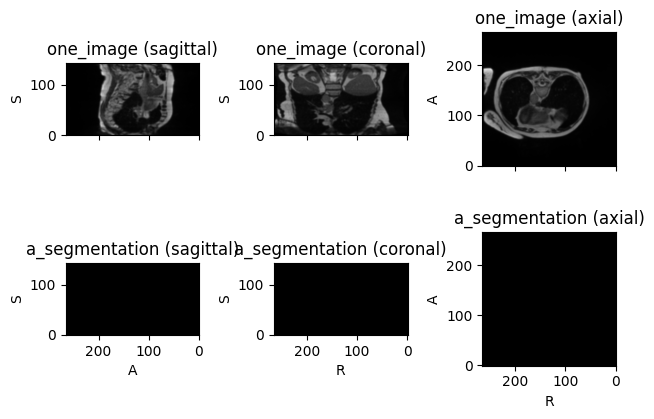

In [29]:
train_subjects_dataset[0]

In [31]:
train_subjects_dataset[0].unload()

In [32]:
g = torch.Generator()
g.manual_seed(42)

In [33]:
patch_size = (64, 64, 64)

# 2. Define a sampler
sampler = tio.data.UniformSampler(patch_size)

# 3. Create the Queue
train_queue = tio.Queue(
    subjects_dataset=train_subjects_dataset,
    max_length=200,           # Maximum number of patches in the queue
    samples_per_volume=10,    # Number of patches extracted per volume per loading
    sampler=sampler,
    num_workers=2,            # Number of worker threads for loading
)

valid_queue = tio.Queue(
    subjects_dataset=valid_subjects_dataset,
    max_length=200,           # Maximum number of patches in the queue
    samples_per_volume=10,    # Number of patches extracted per volume per loading
    sampler=sampler,
    num_workers=2,            # Number of worker threads for loading
)


train_patches_loader = tio.SubjectsLoader(
    train_queue,
    batch_size=8,
    shuffle=True,          # Enables shuffling
    generator=g
)

valid_patches_loader = tio.SubjectsLoader(
    valid_queue,
    batch_size=8,
    shuffle=False,          # Enables shuffling
    generator=g
)

In [34]:
from torch import nn
from torch.nn.functional import pad


class Right(nn.Module):
    def __init__(self, 
               in_chan, out_chan):
        super(Right, self).__init__()
        
        self.conv_1 = nn.Conv3d(in_chan, out_chan, kernel_size = 3, padding = 'same')

        self.conv_2 = nn.Conv3d(out_chan, out_chan, kernel_size = 3, padding = 'same')
        self.BN = nn.BatchNorm3d(out_chan)
        
        self.relu = nn.ReLU()
    
    def forward(self, _input):

            x = self.conv_1(_input)
            x = self.BN(x)
            x = self.relu(x)
            
            x = self.conv_2(x)
            x = self.BN(x)
            output = self.relu(x)

            return output



class Down(nn.Module):
    def __init__(self, 
                 in_chan, out_chan):
        super(Down, self).__init__() 
        
        self.down_step = nn.Sequential(
                nn.MaxPool3d(2),
                Right(in_chan, out_chan))

    def forward(self, _input):
            return self.down_step(_input)


class Up(nn.Module):
    def __init__(self, 
               in_chan, out_chan):
        super(Up, self).__init__() 

        self.up = nn.ConvTranspose3d(in_chan, in_chan // 2, kernel_size=2)
        self.conv = Right(in_chan, out_chan)    
        

    def forward(self, input1, input2):
            
        x1 = self.up(input1)
        
        diffZ = input2.size()[2] - x1.size()[2]
        diffY = input2.size()[3] - x1.size()[3]
        diffX = input2.size()[4] - x1.size()[4]

        x1 = pad(x1, [diffX // 2, diffX - diffX // 2,
                      diffY // 2, diffY - diffY // 2,
                      diffZ // 2, diffZ - diffZ // 2])
        
        x = torch.cat([input2, x1], dim=1)
        return self.conv(x)




class Out(nn.Module):
    def __init__(self, 
               in_chan, out_chan):
        super(Out, self).__init__() 

        self.conv = nn.Conv3d(in_chan, out_chan, kernel_size = 1)  

    def forward(self, x):
        return self.conv(x)




class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, size):
        super(UNet, self).__init__()
        
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.size = size 

        self.inc = Right(n_channels, out_chan = 64)
        
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)
        
        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)
        
        self.outc = Out(64, n_classes)

        self.log = nn.Softmax()

    def forward(self, x):
        x1 = self.inc(x)
        
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        
        logits = self.outc(x)
        
        return logits

    def use_checkpointing(self):
        self.inc = torch.utils.checkpoint(self.inc)
        
        self.down1 = torch.utils.checkpoint(self.down1)
        self.down2 = torch.utils.checkpoint(self.down2)
        self.down3 = torch.utils.checkpoint(self.down3)
        self.down4 = torch.utils.checkpoint(self.down4)
        
        self.up1 = torch.utils.checkpoint(self.up1)
        self.up2 = torch.utils.checkpoint(self.up2)
        self.up3 = torch.utils.checkpoint(self.up3)
        self.up4 = torch.utils.checkpoint(self.up4)
        
        self.outc = torch.utils.checkpoint(self.outc)

In [35]:
class TverskyLoss(nn.Module):
    def __init__(self, alpha: float = 0.2, 
                 beta: float = 1.0, eps: float = 1e-6):
        """
        Custom Tversky Loss Module.
        alpha: controls penalty for false positives.
        beta: controls penalty for false negatives.
        """
        super(TverskyLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.eps = eps

    def forward(self, outputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # Convert raw logits to probabilities
        outputs = F.sigmoid(outputs).to(torch.float32)
        
        # Flatten batch, spatial dimensions
        outputs = outputs.reshape(outputs.shape[0], outputs.shape[1], -1)
        targets = targets.reshape(targets.shape[0], targets.shape[1], -1)
        
        # Calculate True Positives, False Positives, False Negatives
        true_pos = (outputs * targets).sum(dim=2)
        false_pos = ((1 - targets) * outputs).sum(dim=2)
        false_neg = (targets * (1 - outputs)).sum(dim=2)
        
        # Calculate Tversky Index
        tversky_index = (true_pos + self.eps) / (
            true_pos + self.alpha * false_pos + self.beta * false_neg + self.eps
        )
        
        return (1.0 - tversky_index.mean()).to(torch.float32)

In [36]:
from torchmetrics.segmentation import GeneralizedDiceScore

def init_weights(m):
    
    if isinstance(m, nn.Conv3d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.01)
    
        
    elif isinstance(m, (nn.BatchNorm3d)):
        nn.init.constant_(m.weight, 1.0)  
        nn.init.constant_(m.bias, 0.01)   


model = UNet(n_channels = 1, n_classes = 3, size = patch_size).to(dtype=torch.float32, device='cuda')
model.apply(init_weights)

loss_fn = TverskyLoss() 
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3,weight_decay=1e-3) 
metrics = GeneralizedDiceScore(num_classes=3, per_class=True).to(device)

In [ ]:
import tqdm
epochs = 3

for i in range(epochs):
    print(f"Epoch {i+1}")
    
    train_tqdm = tqdm.tqdm(train_patches_loader)
    model.train()
    
    for batch in train_tqdm:
        #N, C, H, W, D -> N, C, D, H, W
        image, masks = batch['one_image'][tio.DATA], batch['a_segmentation'][tio.DATA]
        image, masks = image.to(device), masks.to(device) 
        image, masks = image.permute(0, 1, 4, 2, 3), masks.permute(0, 1, 4, 2, 3)

        optimizer.zero_grad()  #Обнуляем везде градиенти
        model.zero_grad()
        
        output = model(image)
        L = loss_fn(output, masks)#Рахуємо втрати
        L.backward()
        #nn.utils.clip_grad_value_(model.parameters(), clip_value=0.1)
        
        output = (F.sigmoid(output) > 0.3).float() 
        M = metrics(output.to(torch.int64), masks.to(torch.int64))
        
        optimizer.step()   #Оновлюємо ваги в нейронці
        train_tqdm.set_description(f"Train loss: {L.item()}  Metrics loss: {M}") #Виводимо в термінал інформацію про втрати
        train_tqdm.refresh() #Оновлюємо для кожного батчу термінал 
        
    model.eval()
    valid_metrics = torch.tensor([0, 0, 0], dtype = torch.float).to(device)
    val_loss = []
    
    test_tqdm = tqdm.tqdm(valid_patches_loader)
    
    with torch.no_grad():
        for batch in test_tqdm:
            image, masks = batch['one_image'][tio.DATA], batch['a_segmentation'][tio.DATA]
            image, masks = image.to(device), masks.to(device) 
            image, masks = image.permute(0, 1, 4, 2, 3), masks.permute(0, 1, 4, 2, 3)
                
            output = model(image)

            L = loss_fn(output, masks)
            val_loss.append(L.item())
            
            output = torch.round(F.sigmoid(output))
            M = metrics(output.to(torch.int64), masks.to(torch.int64))
            
            valid_metrics = torch.vstack((valid_metrics, M))
            
    print(f"Epoch {i}, Loss: {np.mean(val_loss)} Metrics: {torch.mean(valid_metrics[1:, :], axis = 0)}")


torch.save(model.state_dict(), 'model.pt')

Epoch 1


Train loss: 1.0  Metrics loss: tensor([0., 0., 0.], device='cuda:0'): 100%|██████████| 307/307 [21:43<00:00,  4.25s/it]                                       
100%|██████████| 37/37 [00:55<00:00,  1.50s/it]


Epoch 0, Loss: 0.9488856711903134 Metrics: tensor([0.0814, 0.0195, 0.0349], device='cuda:0')
Epoch 2


Train loss: 1.0  Metrics loss: tensor([0., 0., 0.], device='cuda:0'): 100%|██████████| 307/307 [21:48<00:00,  4.26s/it]                                       
100%|██████████| 37/37 [00:57<00:00,  1.55s/it]


Epoch 1, Loss: 0.9811048652674701 Metrics: tensor([0.0413, 0.0009, 0.0238], device='cuda:0')
Epoch 3


Train loss: 0.9675071239471436  Metrics loss: tensor([0.0489, 0.0063, 0.0000], device='cuda:0'):  31%|███       | 95/307 [06:47<13:18,  3.77s/it]            

In [ ]:
f = train_1.iloc[53]
fig, ax = plt.subplots()

image = cv2.imread(f.path, 
                           cv2.IMREAD_ANYDEPTH)
ax.imshow(image, cmap = 'gray')
  



mask1 = RLE_masking(f.segm[0],
                           image.shape)
mask2 = RLE_masking(f.segm[1],
                           image.shape)
mask3 = RLE_masking(f.segm[2],
                           image.shape)
        


ax.imshow(image, cmap = 'gray')
        
ax.imshow(mask1, alpha = 0.50, )
ax.imshow(mask2, alpha = 0.50)
ax.imshow(mask3, alpha = 0.50)
ax.axis('off')